# Dog Heart Vertebral Heart Size Point Detection 
# 1. Build an object detection model using pytorch

In [24]:
# Import the required Libraries
import os
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from scipy.io import loadmat
import pandas as pd

In [26]:
class DogHeartKeypointDataset(Dataset):
    def __init__(self, root, transform):
        self.root = root
        self.transform = transform
        self.imgs = sorted(os.listdir(os.path.join(root, "Images")))
        self.labels = sorted(os.listdir(os.path.join(root, "Labels")))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "Images", self.imgs[idx])
        label_path = os.path.join(self.root, "Labels", self.labels[idx])
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        img = self.transform(img)
        h_new, w_new = img.shape[1], img.shape[2]

        mat = loadmat(label_path)
        kpts = mat['six_points'].astype(float)
        kpts = torch.as_tensor(kpts, dtype=torch.float32)
        kpts[:, 0] = (w_new / w) * kpts[:, 0]
        kpts[:, 1] = (h_new / h) * kpts[:, 1]
        kpts = kpts.reshape(-1)
        return img, kpts

    def __len__(self):
        return len(self.imgs)

def get_transform(size):
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((size, size)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])


In [25]:
# Define Model
class TinyVHSKeypointModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 12)  # 6 keypoints (x, y)
        )

    def forward(self, x):
        return self.model(x)


# 2. Train your model using [Dog VHS Dataset](https://yuad-my.sharepoint.com/:f:/g/personal/youshan_zhang_yu_edu/ErguFJBE4y9KqzEdWWNlXzMBkTbsBaNX9l856SyvQauwJg?e=L3JOuN)

In [27]:
# Model Training
def train_model(model, dataloader, epochs, device):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, keypoints in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs = imgs.to(device)
            keypoints = keypoints.to(device)

            preds = model(imgs)
            loss = criterion(preds, keypoints)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")
    return model


In [28]:
RESIZED_IMAGE_SIZE = 128
BATCH_SIZE = 4
EPOCHS = 150
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Change this path to your local Train folder
TRAIN_DIR = r'C:\Users\AKSHITHA\Downloads\PROJECT2 NN\Train'

train_set = DogHeartKeypointDataset(TRAIN_DIR, get_transform(RESIZED_IMAGE_SIZE))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

model = TinyVHSKeypointModel()
model = train_model(model, train_loader, EPOCHS, DEVICE)


Epoch 1/150: 100%|███████████████████████████████████████████████████████████████████| 350/350 [01:10<00:00,  4.96it/s]


Epoch 1 Loss: 202113.4890


Epoch 2/150: 100%|███████████████████████████████████████████████████████████████████| 350/350 [01:12<00:00,  4.84it/s]


Epoch 2 Loss: 45212.5484


Epoch 3/150: 100%|███████████████████████████████████████████████████████████████████| 350/350 [01:11<00:00,  4.87it/s]


...

Epoch 148 Loss: 14818.4637


Epoch 149/150: 100%|█████████████████████████████████████████████████████████████████| 350/350 [00:47<00:00,  7.32it/s]


Epoch 149 Loss: 14080.9810


Epoch 150/150: 100%|█████████████████████████████████████████████████████████████████| 350/350 [00:48<00:00,  7.23it/s]

Epoch 150 Loss: 14599.7444


# 3.Evaluate your model using the test images with the [software](https://github.com/YoushanZhang/Dog-Cardiomegaly_VHS)

In [45]:
# Predictions on test set and generating CSV file 
def predict_and_save(model, image_folder, save_path, image_size, device):
    model.eval()
    transform = get_transform(image_size)
    preds = []

    print("Reading test images from:", image_folder)

    with torch.no_grad():
        for fname in sorted(os.listdir(image_folder)):
            if not fname.endswith(".png"):
                continue
            print("Predicting:", fname)
            path = os.path.join(image_folder, fname)
            img = Image.open(path).convert("RGB")
            orig_w, orig_h = img.size

            transformed = transform(img).unsqueeze(0).to(device)
            output = model(transformed).cpu().squeeze().reshape(-1, 2)
            output[:, 0] *= (orig_w / image_size)
            output[:, 1] *= (orig_h / image_size)
            vhs = calculate_vhs(output.numpy())
            preds.append((fname, round(vhs, 4)))

    if preds:
        with open(save_path, "w") as f:
            for name, vhs in preds:
                f.write(f"{name},{vhs}\n")
        print(f"CSV saved with {len(preds)} predictions → {save_path}")
    else:
        print(" No predictions were made. Check if the folder contains .png images.")


In [46]:
TEST_DIR = r"C:\Users\AKSHITHA\Downloads\PROJECT2 NN\Test_Images\Images"
OUTPUT_CSV = r"C:\Users\AKSHITHA\Downloads\test_predictions112233.csv"

predict_and_save(model, TEST_DIR, OUTPUT_CSV, RESIZED_IMAGE_SIZE, DEVICE)


Reading test images from: C:\Users\AKSHITHA\Downloads\PROJECT2 NN\Test_Images\Images
Predicting: 100.png
Predicting: 1621.png
Predicting: 1622.png
Predicting: 1623.png
Predicting: 1624.png
Predicting: 1625.png
Predicting: 1626.png
Predicting: 1627.png
Predicting: 1628.png
Predicting: 1629.png
Predicting: 1630.png
Predicting: 1631.png
Predicting: 1632.png
Predicting: 1633.png
Predicting: 1634.png
Predicting: 1635.png
Predicting: 1636.png
Predicting: 1637.png
Predicting: 1638.png
Predicting: 1639.png
Predicting: 1640.png
Predicting: 1641.png
Predicting: 1642.png
Predicting: 1643.png
Predicting: 1644.png
Predicting: 1645.png
Predicting: 1646.png
Predicting: 1647.png
Predicting: 1648.png
Predicting: 1649.png
Predicting: 1650.png
Predicting: 1651.png
Predicting: 1652.png
Predicting: 1653.png
Predicting: 1654.png
Predicting: 1655.png
Predicting: 1656.png
Predicting: 1657.png
Predicting: 1658.png
Predicting: 1659.png
Predicting: 1660.png
Predicting: 1661.png
Predicting: 1662.png
Predicting: 1

In [42]:
# Path to save model file 
SAVE_PATH = r"C:\Users\AKSHITHA\Downloads\dog_vhs_model.pt"

# Save model state_dict
torch.save(model.state_dict(), SAVE_PATH)

print(f" Model weights saved to: {SAVE_PATH}")


 Model weights saved to: C:\Users\AKSHITHA\Downloads\dog_vhs_model.pt


# 4. Your results should be achieved 85%. VHS = 6(AB+CD)/EF

## (10 points, accuracy < 75% --> 0 points)

As it is shown in the screenshot below, I got an accuracy of 76 %

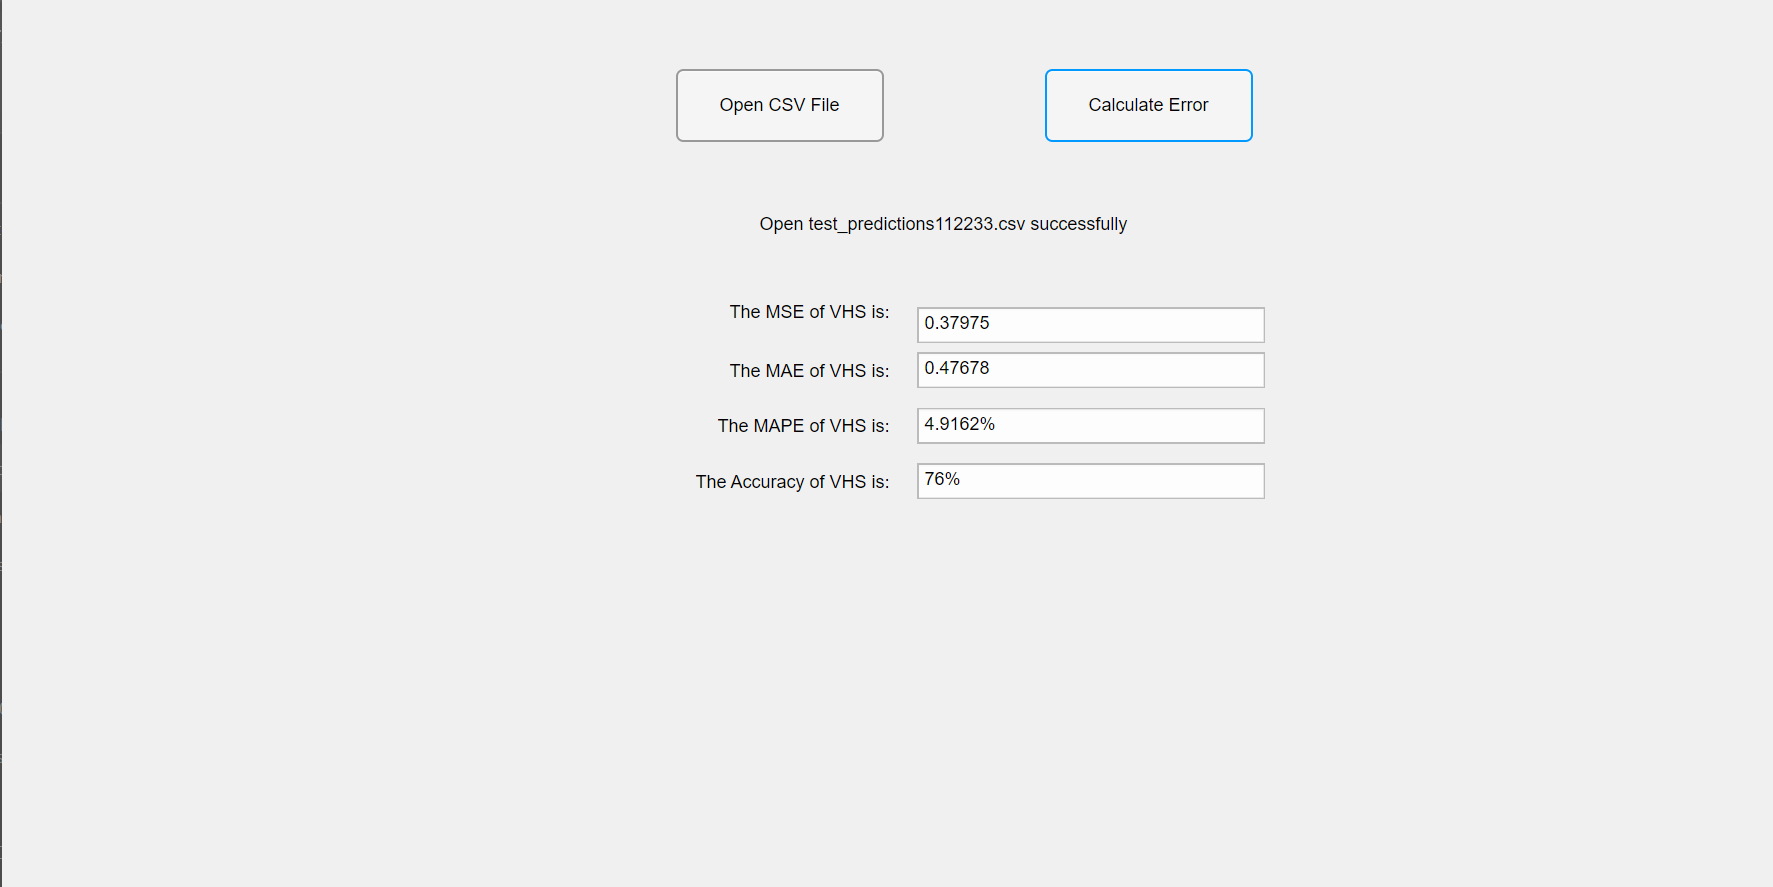

# 5. Show the comprison between predictions and ground truth
## You need to add the title with: image name, predicted VHS and Ground Truth VHS

# Please show the comprison results of images: 1420.png, 1479.png and 1530.png from Valid dataset

In [31]:
def calculate_vhs(kpts):
    kpts = kpts.reshape(6, 2)
    AB = np.linalg.norm(kpts[0] - kpts[1])
    CD = np.linalg.norm(kpts[2] - kpts[3])
    EF = np.linalg.norm(kpts[4] - kpts[5])
    return 6 * (AB + CD) / EF


In [38]:
# Comparison between predictions and ground truth
def draw_vhs(model, image_dir, label_dir, filenames, transform, image_size, device):
    model.eval()
    fig, axes = plt.subplots(1, len(filenames), figsize=(18, 6))  # 3 images in a row

    for idx, fname in enumerate(filenames):
        # Load image and label
        img_path = os.path.join(image_dir, fname)
        label_path = os.path.join(label_dir, fname.replace(".png", ".mat"))
        img = Image.open(img_path).convert("RGB")
        orig_w, orig_h = img.size
        transformed = transform(img).unsqueeze(0).to(device)

        # Predict keypoints
        with torch.no_grad():
            output = model(transformed).cpu().squeeze().reshape(-1, 2)
            output[:, 0] *= (orig_w / image_size)
            output[:, 1] *= (orig_h / image_size)
            pred_kpts = output.numpy()

        # Load GT keypoints
        mat = loadmat(label_path)
        gt_kpts = mat["six_points"].astype(float)
        gt_vhs = float(mat["VHS"].item())
        pred_vhs = calculate_vhs(pred_kpts)

        # Plot on individual subplot
        ax = axes[idx]
        ax.imshow(img)
        pairs = [(0, 1), (2, 3), (4, 5)]

        for i, j in pairs:
            ax.plot([gt_kpts[i][0], gt_kpts[j][0]],
                    [gt_kpts[i][1], gt_kpts[j][1]],
                    color='green', linewidth=2)
            ax.plot([pred_kpts[i][0], pred_kpts[j][0]],
                    [pred_kpts[i][1], pred_kpts[j][1]],
                    color='red', linestyle='--', linewidth=2)

        ax.scatter(gt_kpts[:, 0], gt_kpts[:, 1], c='green', label='Ground Truth', marker='o')
        ax.scatter(pred_kpts[:, 0], pred_kpts[:, 1], c='red', label='Predicted', marker='x')

        ax.set_title(f"{fname}\nPred VHS: {round(pred_vhs, 2)}, GT VHS: {round(gt_vhs, 2)}")
        ax.axis("off")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, fontsize='medium')
    plt.tight_layout()
    plt.show()


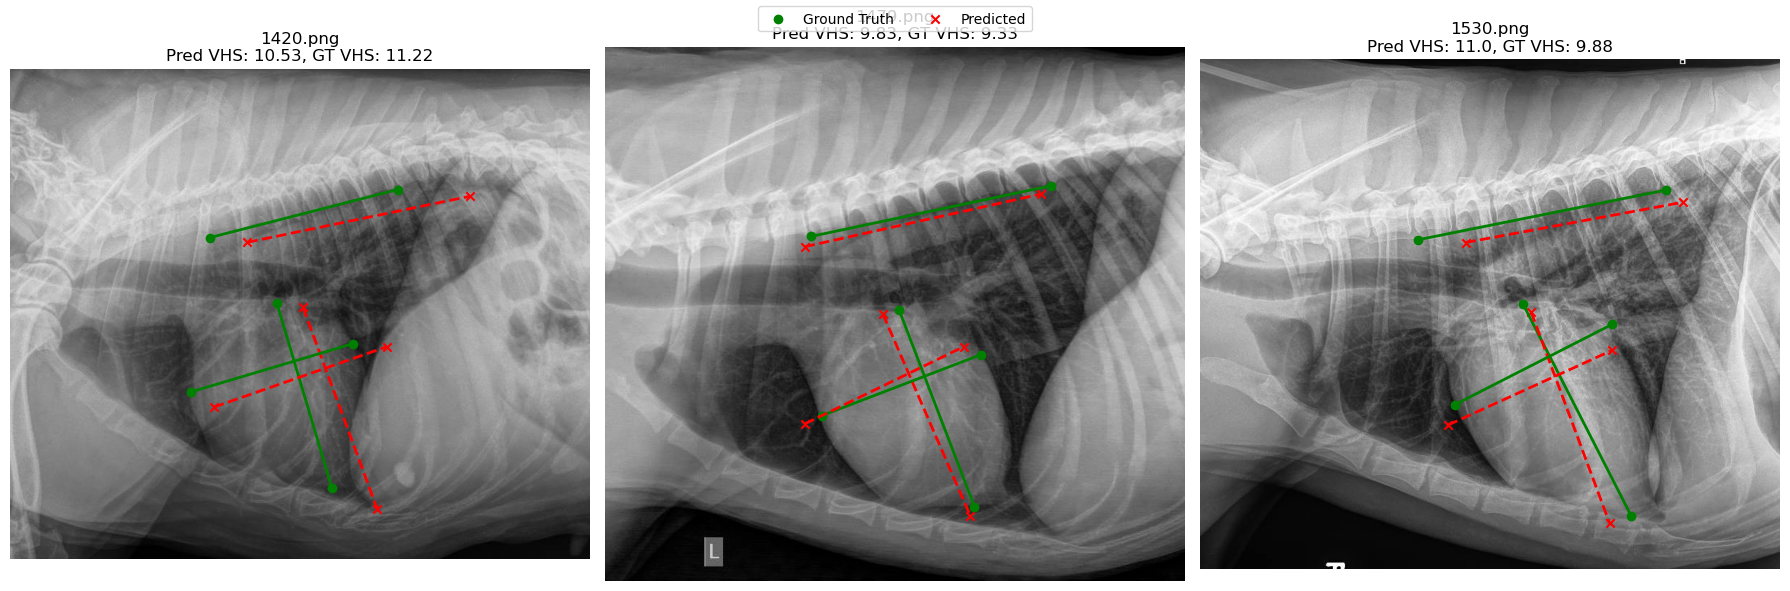

In [39]:
image_dir = r"C:\Users\AKSHITHA\Downloads\PROJECT2 NN\Valid\Images"
label_dir = r"C:\Users\AKSHITHA\Downloads\PROJECT2 NN\Valid\Labels"
image_names = ["1420.png", "1479.png", "1530.png"]

draw_vhs(model, image_dir, label_dir, image_names,
                      get_transform(RESIZED_IMAGE_SIZE),
                      RESIZED_IMAGE_SIZE,
                      DEVICE)


# 6. Write a three-page report using LaTex and upload your paper to ResearchGate or Arxiv, and put your paper link here.

https://www.researchgate.net/publication/390748463_Keypoint-Based_VHS_Prediction_in_Canine_Cardiomegaly_Using_CNN